In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [3]:
df = pd.read_excel(r"C:\Users\Bharath Venkatesh\Downloads\Bank_Loan\Bank Loan Project\financial_loan_data_excel.xlsx")
df.head(10)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
5,1062608,CA,INDIVIDUAL,3 years,Studio 94 Corp,C,RENT,2021-07-17,2021-03-16,2021-08-12,...,C3,36 months,Not Verified,28000.0,0.1260,275.96,0.1465,8000,11,8637
6,1067441,TX,INDIVIDUAL,10+ years,American Airlines,C,MORTGAGE,2021-11-19,2021-06-14,2021-12-13,...,C2,36 months,Verified,94800.0,0.2453,205.86,0.1427,6000,30,7218
7,1066424,PA,INDIVIDUAL,10+ years,SCI Mahanoy,A,OWN,2021-06-11,2021-07-14,2021-07-14,...,A4,36 months,Source Verified,59000.0,0.0665,172.10,0.0790,5500,23,6172
8,1065254,FL,INDIVIDUAL,10+ years,Tech Data Corp,A,MORTGAGE,2021-09-02,2021-06-15,2021-10-12,...,A5,36 months,Verified,116400.0,0.0394,762.08,0.0890,24000,31,8650
9,1064589,MI,INDIVIDUAL,10+ years,teltow contracting,B,MORTGAGE,2021-02-09,2021-03-16,2021-03-16,...,B5,60 months,Not Verified,36000.0,0.1773,93.21,0.1269,4125,21,5551


In [4]:
df.shape

(38576, 24)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

In [6]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
38571    False
38572    False
38573    False
38574    False
38575    False
Length: 38576, dtype: bool

In [8]:
total_loan_applications = df['id'].count()
print("Total_Loan_Application: ",total_loan_applications)

Total_Loan_Application:  38576


In [9]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month== latest_month)]
mtd_loan_applications = mtd_data['id'].count()
print(f"MTD Loan Applications(for{latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")

MTD Loan Applications(forDecember 2021):4314


In [10]:
total_funded_amount = df['loan_amount'].sum()
print(f"Total Funded amount: ${(total_funded_amount)/1000000:.2f}m")

Total Funded amount: $435.76m


In [11]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month== latest_month)]
mtd_loan_amount = mtd_data['loan_amount'].sum()
print(f"MTD Loan Amount(for{latest_issue_date.strftime('%B %Y')}):${mtd_loan_amount/1000000:.2f}m")

MTD Loan Amount(forDecember 2021):$53.98m


In [12]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month== latest_month)]
mtd_recieved_amount = mtd_data['total_payment'].sum()
print(f"MTD Recieved Amount(for{latest_issue_date.strftime('%B %Y')}):${mtd_recieved_amount/1000000:.2f}m")

MTD Recieved Amount(forDecember 2021):$58.07m


In [13]:
avg_int_rate= df['int_rate'].mean()
print(f"Avg Interest Rate:{(avg_int_rate)*100:.2f}%")

Avg Interest Rate:12.05%


In [14]:
avg_dti = df['dti'].mean()
print(f"Avg DTI:{(avg_dti)*100:.2f}%")

Avg DTI:13.33%


In [15]:
good_loans = df[df['loan_status'].isin(["Fully Paid","Current"])]
good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_recieved_amount = good_loans['total_payment'].sum()

print("Total Good Loans Application:",good_loan_applications)
print(f"Good Loans Percentage: {(good_loan_applications/total_loan_applications)*100:.2f}%")
print(f"Good Loans Funded Amount: ${good_loan_funded_amount/1000000:.2f}m")
print(f"Good Loans Payment Amount: ${good_loan_recieved_amount/1000000:.2f}m")


Total Good Loans Application: 33243
Good Loans Percentage: 86.18%
Good Loans Funded Amount: $370.22m
Good Loans Payment Amount: $435.79m


In [16]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]
bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_recieved_amount = bad_loans['total_payment'].sum()

print("Total bad Loans Application:",bad_loan_applications)
print(f"Bad Loans Percentage: {(bad_loan_applications/total_loan_applications)*100:.2f}%")
print(f"Bad Loans Funded Amount: ${bad_loan_funded_amount/1000000:.2f}m")
print(f"Bad Loans Payment Amount: ${bad_loan_recieved_amount/1000000:.2f}m")

Total bad Loans Application: 5333
Bad Loans Percentage: 13.82%
Bad Loans Funded Amount: $65.53m
Bad Loans Payment Amount: $37.28m


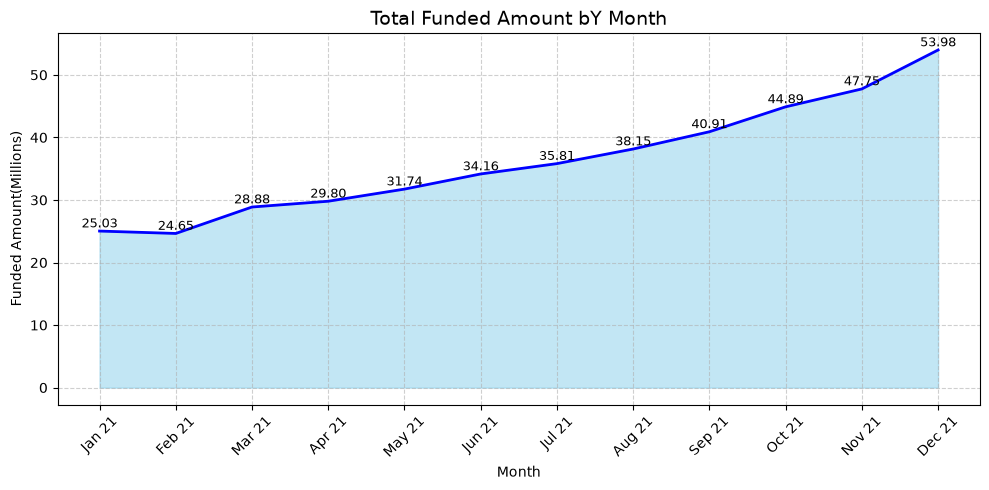

In [17]:
sum_loan_amount=df['loan_amount'].sum()
loan_amount_millions = sum_loan_amount/1000000
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %y'))
    .groupby('month_name',sort = False)['loan_amount']
    .sum()
    .div(1_000_000)
    .reset_index(name = 'loan_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color = 'skyblue',alpha = 0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color = 'blue',linewidth =2)

for i, row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_millions']+0.1,f"{row['loan_amount_millions']:.2f}",
             ha='center',va='bottom',fontsize=9,rotation=0,color='black')

plt.title('Total Funded Amount bY Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount(Millions)')
plt.xticks(ticks=range(len(monthly_funded)),labels=monthly_funded['month_name'],rotation=45)
plt.grid(True, linestyle ='--',alpha=0.6)
plt.tight_layout()
plt.show()    


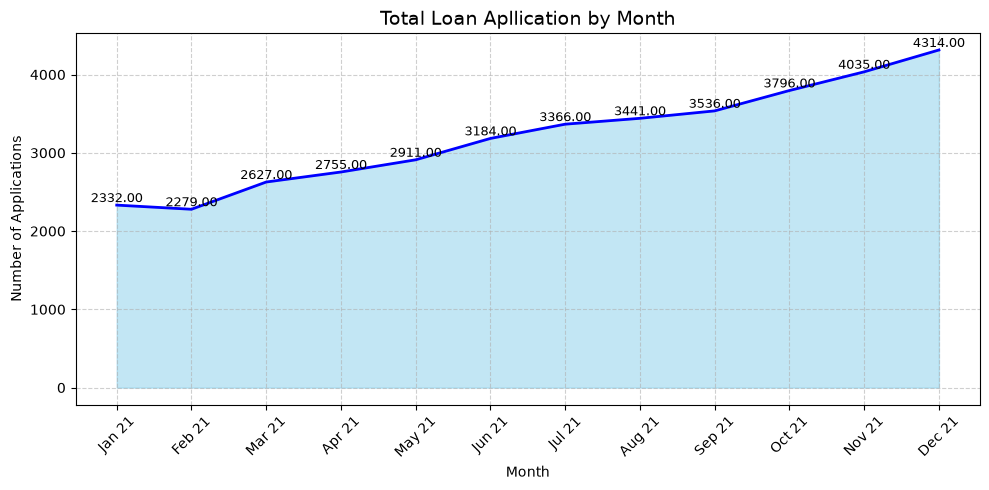

In [18]:

monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %y'))
    .groupby('month_name',sort = False)['loan_amount']
    .count()
    .reset_index(name = 'loan_applications_count')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['loan_applications_count'],color = 'skyblue',alpha = 0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_applications_count'],color = 'blue',linewidth =2)

for i, row in monthly_applications.iterrows():
    plt.text(i,row['loan_applications_count']+0.1,f"{row['loan_applications_count']:.2f}",
             ha='center',va='bottom',fontsize=9,rotation=0,color='black')

plt.title('Total Loan Apllication by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)),labels=monthly_applications['month_name'],rotation=45)
plt.grid(True, linestyle ='--',alpha=0.6)
plt.tight_layout()
plt.show()    


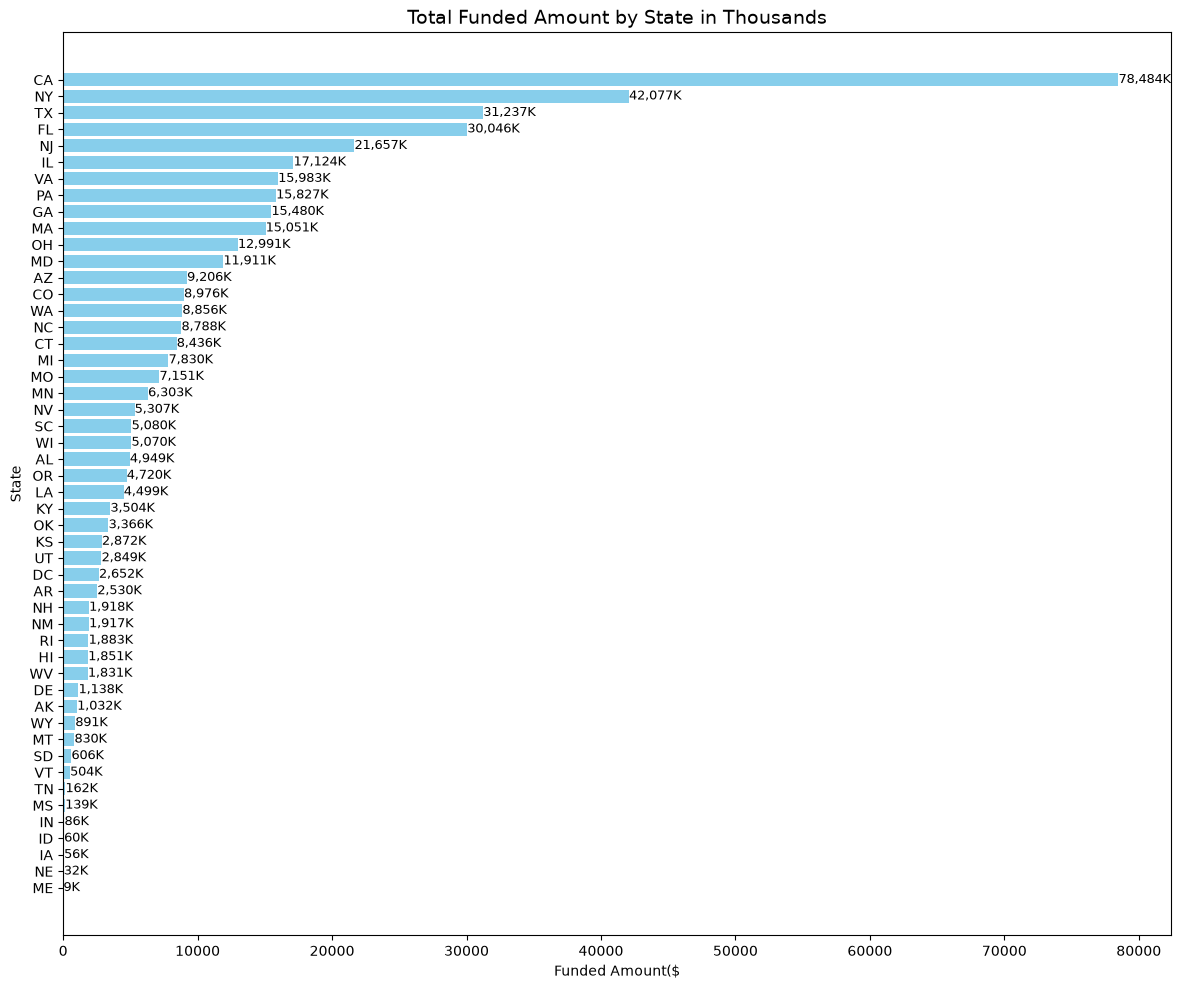

In [19]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_K= state_funding/1000

plt.figure(figsize=(12,10))
bars = plt.barh(state_funding_K.index,state_funding_K.values,color = 'skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height()/2,
         f'{width:,.0f}K',va='center', fontsize =9)

plt.title('Total Funded Amount by State in Thousands', fontsize=14)
plt.xlabel('Funded Amount($')
plt.ylabel('State')
plt.tight_layout()
plt.show()

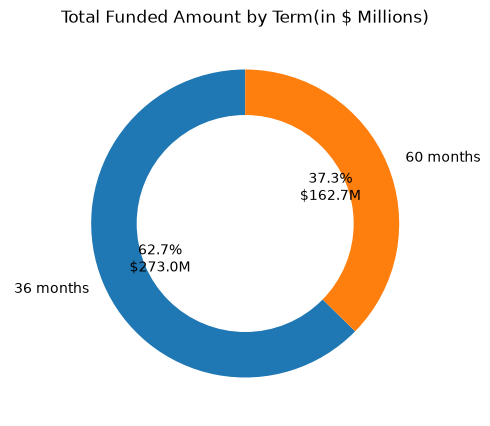

In [20]:
term_funding_m = df.groupby('term')['loan_amount'].sum()/1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funding_m,
    labels = term_funding_m.index ,
    autopct= lambda p: f"{p:.1f}%\n${p * term_funding_m.sum() / 100:.1f}M",
    startangle= 90,
    wedgeprops= {'width': 0.4}                                
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color = 'white'))
plt.title("Total Funded Amount by Term(in $ Millions)")
plt.show()

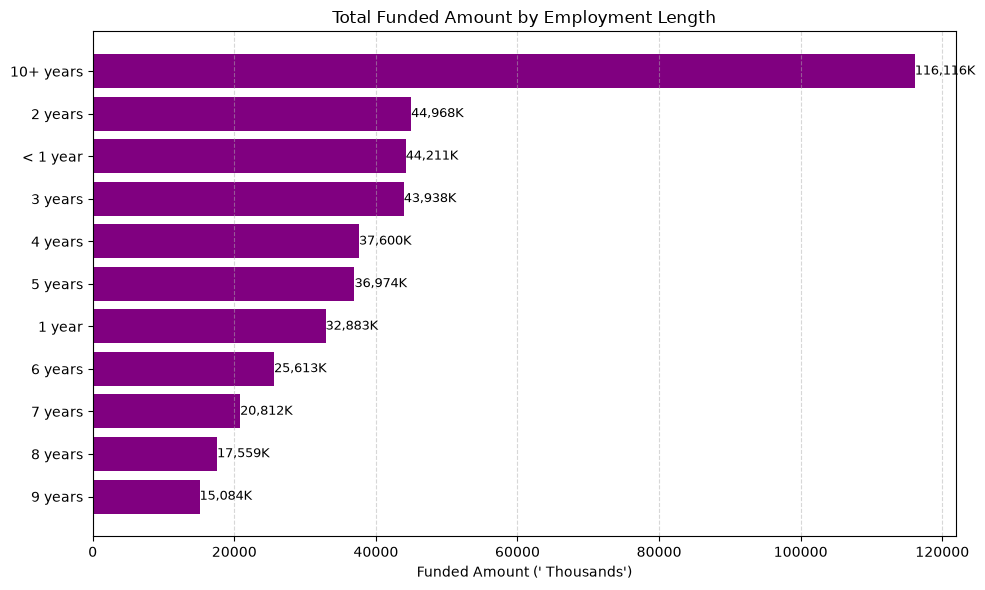

In [21]:
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"{width:,.0f}K", va='center', fontsize=9)

plt.xlabel("Funded Amount (' Thousands')")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

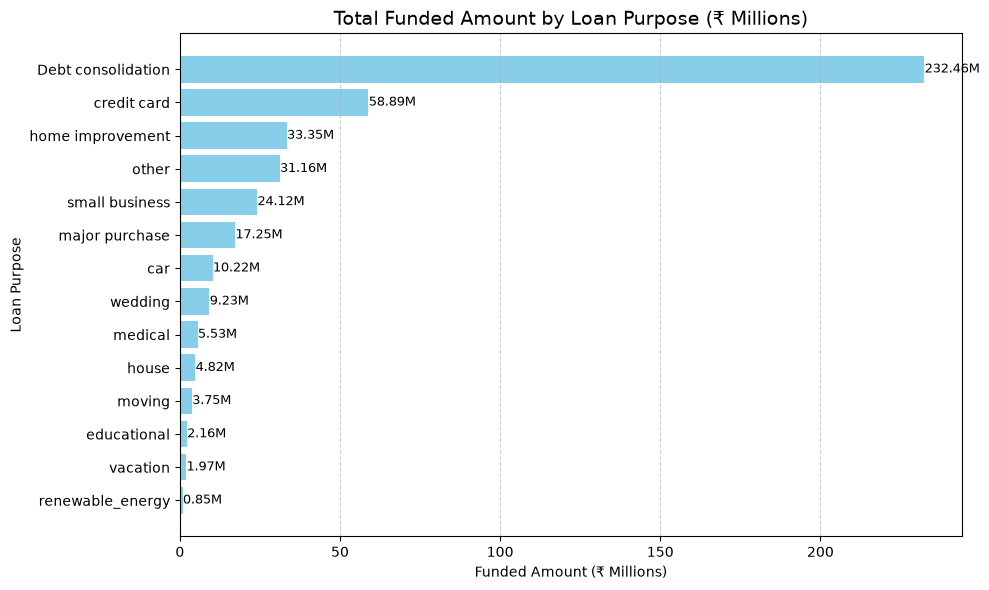

In [22]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values() / 1000000)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    purpose_funding_millions.index,
    purpose_funding_millions.values,
    color='skyblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Funded Amount (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()